# ==================================================
# TP4 - Data Mining : Segmentation RFM avec K-Means
# ==================================================

# Vidéo de présentation du projet

# https://www.loom.com/share/f381a3fc298542548899fc901f008d2e
# Réalisé par :
# Nom : Khadijetou Ahmed Salem Dieng
# Matricule : (C29387)

<br>

<br><br><br>

# Imports

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

<br>

# Phase 1 : Acquisition et Ingestion

##  Q1 Télécharger le dataset

###   Télécharger ici : Dataset : [Online Retail Dataset](https://archive.ics.uci.edu/ml/datasets/Online+Retail)

<br>



##  Q2 Charger CSV et convertir en Parquet

In [59]:
import pandas as pd
import time

# lecture CSV
start = time.time()
df = pd.read_csv("../data/Online_retail.csv", encoding='ISO-8859-1')
csv_time = time.time() - start

# sauvegarde parquet
df.to_parquet("../data/Online_retail.parquet")

# lecture parquet
start = time.time()
df_parquet = pd.read_parquet("../data/Online_retail.parquet")
parquet_time = time.time() - start

print("Temps CSV :", csv_time)
print("Temps Parquet :", parquet_time)

Temps CSV : 1.0356130599975586
Temps Parquet : 0.3101949691772461


### le format
### Parquet est-il privilégié:

✔️ plus rapide<br>
✔️ compressé<BR>
✔️ moins d’espace disque<br>
✔️ très utilisé en Big Data (Apache Spark https://spark.apache.org/)

# Phase 2 : Data Cleaning

  ## Q3 Valeurs manquantes

In [60]:
missing = df.isnull().mean()*100
print(missing)

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64


### Supprimer les clients sans ID :

In [61]:
df = df.dropna(subset=['CustomerID'])
print(df.shape)

(406829, 8)


<br>

## Q4 Nettoyage métier

### Transactions annulées :

In [62]:
# Suppression des prix négatifs
df = df[df['Quantity'] > 0]
# Suppression des prix négatifs ou nuls

df = df[df['UnitPrice'] > 0]

## Q5 Créer MontantTotal

In [63]:
# Création de MontantTotal

df['MontantTotal'] = df['Quantity'] * df['UnitPrice']

print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  MontantTotal  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom         15.30  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom         20.34  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom         22.00  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom         20.34  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom         20.34  


<br>

# Phase 3 : Feature Engineering (RFM)

 ### Convertir date :

In [64]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

### Date référence :

In [65]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

<br>

## Q6 Créer df_RFM

In [66]:
df_RFM = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,
    "InvoiceNo": "nunique",
    "MontantTotal": "sum"
})

df_RFM.columns = ["Recence", "Frequence", "Montant"]

print(df_RFM.head())

            Recence  Frequence   Montant
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


## Q7 Histogramme Montant

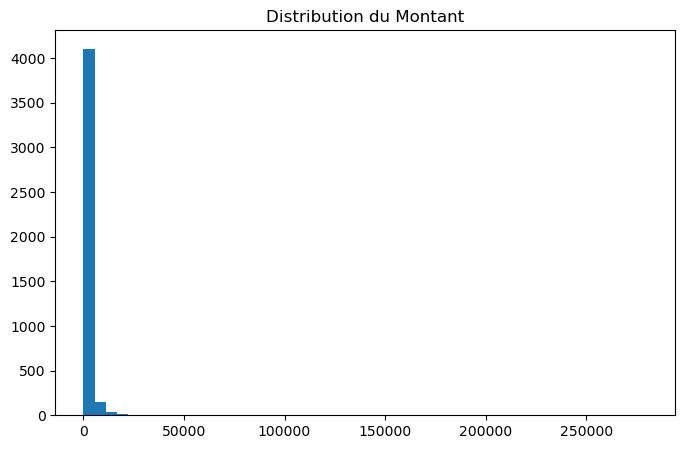

In [67]:
plt.figure(figsize=(8,5))
plt.hist(df_RFM["Montant"], bins=50)
plt.title("Distribution du Montant")
plt.show()

### Observation :
 
### ➡️asymétrie à droite (skewness)

<br>

## Q8 Transformation logarithmique

In [68]:
df_log = np.log1p(df_RFM)
print(df_log.head())

             Recence  Frequence    Montant
CustomerID                                
12346.0     5.789960   0.693147  11.253955
12347.0     1.098612   2.079442   8.368925
12348.0     4.330733   1.609438   7.494564
12349.0     2.995732   0.693147   7.472245
12350.0     5.739793   0.693147   5.815324


## Q9 Standardisatio

In [69]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)
print(df_scaled[:5])

[[ 1.46199281 -0.95521426  3.70622476]
 [-2.03873442  1.07442519  1.41184341]
 [ 0.37310424  0.38630445  0.7164889 ]
 [-0.62308592 -0.95521426  0.6987394 ]
 [ 1.42455753 -0.95521426 -0.6189622 ]]


 cette étape est mathématiquement obligatoire pour le K-Means
Parce que K-Means utilise la distance euclidienne.

d(x,y)=\sqrt{\sum_{i=1}^{n}(x_i-y_i)^2}

Si une variable est grande, elle domine tout.

<br>

# Phase 4 : Clustering





## Q10 Méthode du coude

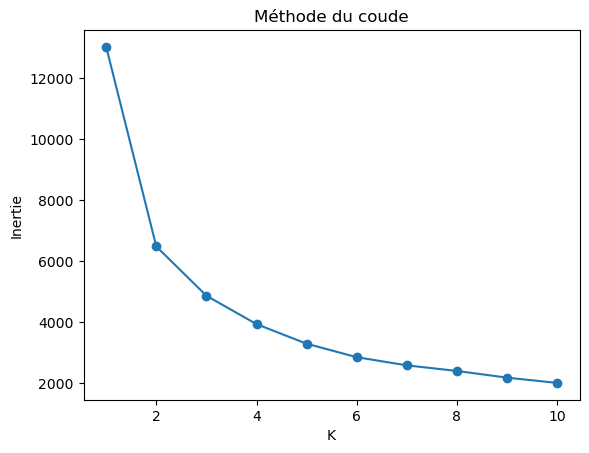

In [70]:
inertias = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(df_scaled)
    inertias.append(km.inertia_)

plt.plot(range(1,11), inertias, marker='o')
plt.xlabel("K")
plt.ylabel("Inertie")
plt.title("Méthode du coude")
plt.show()

<br>

# Q11 Silhouette Score

In [71]:
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(k, score)

2 0.43319275011132063
3 0.3360125435154917
4 0.3371343622222519
5 0.31731213206663567
6 0.3142698080619326
7 0.2874792907815653
8 0.26816320360101
9 0.27843999047689816
10 0.2791393695495976


# Q12 Modèle final

### Exemple si k=4 :

In [72]:
kmeans = KMeans(n_clusters=4, random_state=42)
df_RFM["Cluster"] = kmeans.fit_predict(df_scaled)
print(df_RFM.head())

            Recence  Frequence   Montant  Cluster
CustomerID                                       
12346.0         326          1  77183.60        2
12347.0           2          7   4310.00        1
12348.0          75          4   1797.24        2
12349.0          19          1   1757.55        0
12350.0         310          1    334.40        3


<br>

# Phase 5 : Data Storytelling

### Q13 Moyennes par cluster

In [73]:
cluster_summary = df_RFM.groupby("Cluster").mean()
print(cluster_summary)

            Recence  Frequence      Montant
Cluster                                    
0         18.124253   2.148148   551.819534
1         12.131285  13.713687  8074.266872
2         71.084399   4.083546  1802.829005
3        182.496898   1.318238   343.450032


# Q14 Profilage

### Exemple :

* faible R + forte F + fort M = Champions
* forte R + faible F + faible M = Clients à risque

In [74]:
 # Nombre de clients par cluster

print(df_RFM['Cluster'].value_counts())

Cluster
3    1612
2    1173
0     837
1     716
Name: count, dtype: int64


# Q15 — Visualisation 2D

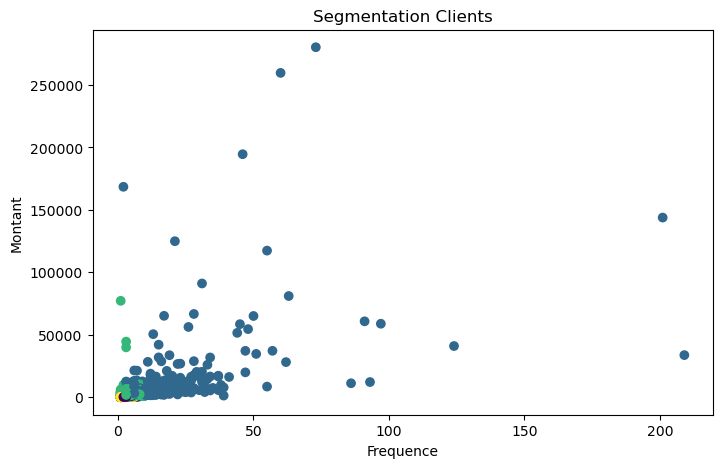

In [75]:


plt.figure(figsize=(8,5))

plt.scatter(
    df_RFM['Frequence'],
    df_RFM['Montant'],
    c=df_RFM['Cluster']
)

plt.xlabel('Frequence')

plt.ylabel('Montant')

plt.title('Segmentation Clients')

plt.show()

### Visualisation 3D

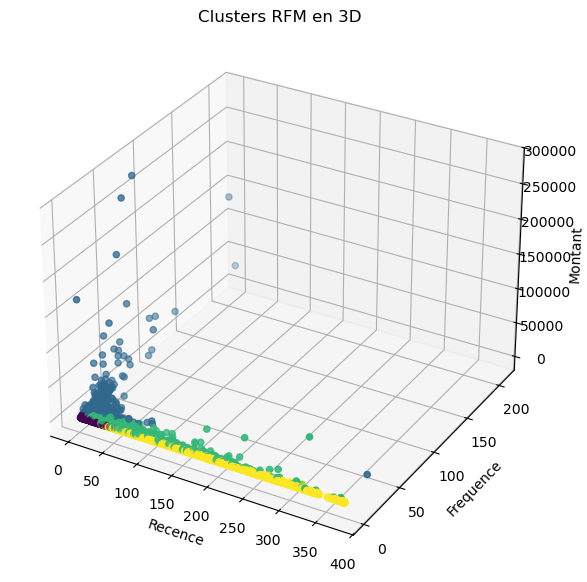

In [76]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_RFM['Recence'],
    df_RFM['Frequence'],
    df_RFM['Montant'],
    c=df_RFM['Cluster']
)

ax.set_xlabel('Recence')

ax.set_ylabel('Frequence')

ax.set_zlabel('Montant')

plt.title('Clusters RFM en 3D')

plt.show()

<br><b>



# Conclusion

#### Dans ce projet, j'ai appliqué une pipeline complète de Data Mining
#### sur le dataset Online Retail.
#### J'ai commencé par le nettoyage des données
#### (suppression des valeurs manquantes et des anomalies),
#### puis j'ai construit le modèle RFM :
#### Recence, Frequence et Montant.
#### Ensuite, j'ai normalisé les données et utilisé
#### l’algorithme K-Means pour segmenter les clients.
#### Grâce à la méthode du coude et au Silhouette Score,
#### j'ai choisi le nombre optimal de clusters.
#### Enfin, l’analyse des clusters a permis d’identifier
#### différents profils clients comme :
#### les champions, les clients fidèles et les clients à risque.
#### Cette segmentation permet à l’entreprise
#### d’adapter ses stratégies marketing
#### et d’améliorer la fidélisation des clients.

<br><b><br>